# Longitudinal Cardiovascular Drift Research Notebook

## Investigating the Causes of Cardiovascular Drift in Garmin FIT Running Data

This notebook is structured as a field-based endurance physiology study. It integrates easy runs, interval or threshold sessions, and strength sessions to test which internal-load, external-load, heat, and recovery variables are most strongly associated with cardiovascular drift during running.

### Primary outcome
- Aerobic decoupling during easy runs, expressed as percentage drift in the speed-to-heart-rate relationship.

### Secondary outcomes
- Power-to-heart-rate decoupling
- Recovery heart-rate kinetics
- Longitudinal adaptation in efficiency, durability, and fatigue resilience

### Study framing
This workflow is intended to resemble an endurance research paper or conference poster: explicit hypotheses, reproducible data loading, modular feature engineering, exploratory and predictive statistics, publication-ready figures, and automated scientific interpretation.

## Hypotheses

1. Higher heat exposure and greater sweat loss will be associated with larger cardiovascular drift.
2. Longer session duration and slower post-exercise heart-rate recovery will predict larger drift.
3. Mechanical variables that reflect economical movement, especially cadence and power stability, will show inverse relationships with drift.
4. Recent hard training exposure from interval and strength sessions will increase drift in subsequent easy runs when recovery is incomplete.
5. Longitudinal adaptation should appear as lower drift, improved efficiency factor, and improved recovery kinetics over time under comparable durations.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["figure.dpi"] = 140

def display_markdown(text: str) -> None:
    if display is not None and Markdown is not None:
        display(Markdown(text))
    else:
        print(text)

print("Scientific stack loaded successfully.")

Scientific stack loaded successfully.


In [2]:
def resolve_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not resolve the project root from the current working directory.")

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import hr_improvement_tracker as easy_tracker
from interval_high_intensity_analysis import analyze_interval_workouts
from strength_endurance_integration import analyze_strength_endurance

EASY_RAW_DIR = PROJECT_ROOT / "data/activities/easy/raw"
INTERVAL_RAW_DIR = PROJECT_ROOT / "data/activities/interval/raw"
STRENGTH_RAW_DIR = PROJECT_ROOT / "data/activities/strength/raw"
EASY_REPORT_DIR = PROJECT_ROOT / "reports/easy"
INTERVAL_REPORT_DIR = PROJECT_ROOT / "reports/interval"
STRENGTH_REPORT_DIR = PROJECT_ROOT / "reports/strength"
POSTER_OUTPUT = EASY_REPORT_DIR / "cardiovascular_drift_research_panels.png"
SUMMARY_OUTPUT = EASY_REPORT_DIR / "cardiovascular_drift_research_summary.md"
REFRESH_SOURCE_DATA = False
ROLLING_WINDOW_DAYS = 3

print(f"Project root: {PROJECT_ROOT}")
print(f"Easy FIT files: {len(list(EASY_RAW_DIR.glob('*.fit')))}")
print(f"Interval FIT files: {len(list(INTERVAL_RAW_DIR.glob('*.fit')))}")
print(f"Strength FIT files: {len(list(STRENGTH_RAW_DIR.glob('*.fit')))}")

Project root: C:\Users\A717631\repo\theEagle
Easy FIT files: 11
Interval FIT files: 5
Strength FIT files: 10


## Data Ingestion Strategy

The repository already contains validated extraction pipelines for each session type. This notebook reuses them instead of redefining physiology metrics ad hoc.

- Easy runs: steady-state metrics, aerobic decoupling, recovery heart rate, settled heart rate, fatigue resilience, and longitudinal scorecard fields
- Interval and threshold sessions: repeat structure, cardiac drift, power fade, cadence collapse, HR recovery between repetitions, and thermal context
- Strength sessions: heart-rate drift, estimated sweat loss, recovery-cost score, and interaction windows around easy runs

Set `REFRESH_SOURCE_DATA = True` in the previous cell if you want the notebook to regenerate the report tables directly from the raw FIT files before analysis.

In [3]:
def read_csv_with_dates(path: Path, date_cols: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path)
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def load_or_refresh_datasets(refresh: bool = False) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    easy_csv = EASY_REPORT_DIR / "hr_improvement_analysis.csv"
    interval_csv = INTERVAL_REPORT_DIR / "interval_workouts_dataset.csv"
    strength_csv = STRENGTH_REPORT_DIR / "strength_endurance_sessions.csv"

    if refresh or not easy_csv.exists():
        easy_df, weekly_df, _ = easy_tracker.run_analysis(fit_dir=EASY_RAW_DIR, report_dir=EASY_REPORT_DIR)
    else:
        easy_df = read_csv_with_dates(easy_csv, ["date", "filename_date"])
        weekly_df = easy_tracker.build_weekly_summary(easy_df.copy())

    if refresh or not interval_csv.exists():
        analyze_interval_workouts(interval_dir=INTERVAL_RAW_DIR, easy_csv=easy_csv, output_dir=INTERVAL_REPORT_DIR)
    interval_df = read_csv_with_dates(interval_csv, ["date"])

    if refresh or not strength_csv.exists():
        analyze_strength_endurance(strength_dir=STRENGTH_RAW_DIR, running_csv=easy_csv, output_dir=STRENGTH_REPORT_DIR)
    strength_df = read_csv_with_dates(strength_csv, ["date"])

    easy_df = easy_df.sort_values("date").reset_index(drop=True)
    interval_df = interval_df.sort_values("date").reset_index(drop=True)
    strength_df = strength_df.sort_values("date").reset_index(drop=True)
    weekly_df = weekly_df.sort_values("week").reset_index(drop=True)
    return easy_df, interval_df, strength_df, weekly_df


easy_df, interval_df, strength_df, weekly_df = load_or_refresh_datasets(refresh=REFRESH_SOURCE_DATA)

print("Loaded datasets:")
print(f"  Easy runs: {easy_df.shape}")
print(f"  Interval sessions: {interval_df.shape}")
print(f"  Strength sessions: {strength_df.shape}")
print(f"  Weekly summary: {weekly_df.shape}")

easy_df[["date", "workout_title", "duration_min", "steady_pace_min_per_km", "aerobic_drift_pct", "avg_temperature_c", "estimated_sweat_loss_l"]].head()

Loaded datasets:
  Easy runs: (11, 128)
  Interval sessions: (5, 38)
  Strength sessions: (10, 30)
  Weekly summary: (6, 16)


,date,workout_title,duration_min,steady_pace_min_per_km,aerobic_drift_pct,avg_temperature_c,estimated_sweat_loss_l
0,2026-04-16 05:27:56,45Min Easy,45.0,7.47,7.21,NaN,0.750
1,2026-04-18 05:53:31,7k Easy,52.8,7.42,2.51,31.0,0.879
2,2026-04-23 05:32:50,45min Easy,45.0,7.37,4.95,30.0,0.750
3,2026-04-25 05:58:04,5k Easy,36.8,7.39,5.40,31.0,0.612
4,2026-04-30 05:26:03,60min Easy,60.1,7.29,7.12,30.0,1.001


## Feature Engineering

The analytical unit is the easy run, because that is where aerobic decoupling is already computed in a stable and comparable way. Interval and strength sessions are treated as recent antecedent exposures.

### Within-run covariates
- Heat exposure, sweat loss, cadence, power, fatigue resilience, recovery HR, settled HR, duration, and pace

### Cross-session exposure covariates
- Prior interval duration and sweat loss in the preceding three days
- Prior strength duration and recovery-cost burden in the preceding three days
- Days since last hard session

### Physiological rationale
These features jointly represent thermoregulatory strain, dehydration proxy, neuromuscular economy, internal load, external load, recovery kinetics, and residual fatigue.

In [4]:
def aggregate_recent_exposure(source_df: pd.DataFrame, anchor_dates: pd.Series, date_col: str, metric_cols: list[str], prefix: str, lookback_days: int = 3) -> pd.DataFrame:
    source = source_df.copy()
    source[date_col] = pd.to_datetime(source[date_col], errors="coerce")
    source = source.dropna(subset=[date_col]).copy()
    rows = []

    for anchor in pd.to_datetime(anchor_dates, errors="coerce"):
        if pd.isna(anchor) or source.empty:
            subset = source.iloc[0:0].copy()
        else:
            lower = anchor - pd.Timedelta(days=lookback_days)
            subset = source[(source[date_col] < anchor) & (source[date_col] >= lower)].copy()

        row = {f"{prefix}_session_count_{lookback_days}d": float(len(subset))}
        for col in metric_cols:
            if col not in subset.columns:
                row[f"{prefix}_{col}_sum_{lookback_days}d"] = 0.0
                row[f"{prefix}_{col}_mean_{lookback_days}d"] = np.nan
                continue
            values = pd.to_numeric(subset[col], errors="coerce").dropna()
            row[f"{prefix}_{col}_sum_{lookback_days}d"] = float(values.sum()) if not values.empty else 0.0
            row[f"{prefix}_{col}_mean_{lookback_days}d"] = float(values.mean()) if not values.empty else np.nan
        rows.append(row)

    return pd.DataFrame(rows)


def days_since_last_session(source_df: pd.DataFrame, anchor_dates: pd.Series, date_col: str, prefix: str) -> pd.Series:
    source = source_df.copy()
    source[date_col] = pd.to_datetime(source[date_col], errors="coerce")
    source = source.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    values = []

    for anchor in pd.to_datetime(anchor_dates, errors="coerce"):
        if pd.isna(anchor) or source.empty:
            values.append(np.nan)
            continue
        prior = source[source[date_col] < anchor]
        if prior.empty:
            values.append(np.nan)
            continue
        delta = anchor - prior.iloc[-1][date_col]
        values.append(float(delta.total_seconds() / 86400.0))

    return pd.Series(values, name=f"days_since_last_{prefix}")


def build_study_dataset(easy_runs: pd.DataFrame, intervals: pd.DataFrame, strengths: pd.DataFrame, lookback_days: int = 3) -> pd.DataFrame:
    df = easy_runs.copy().sort_values("date").reset_index(drop=True)
    df["duration_h"] = df["duration_min"] / 60.0
    df["pace_mps"] = 1000.0 / (df["steady_pace_min_per_km"] * 60.0)
    df["sweat_rate_ml_per_h"] = df["estimated_sweat_loss_ml"] / df["duration_h"]
    df["thermal_strain_index"] = df["avg_temperature_c"] * df["duration_h"]
    df["recovery_efficiency_index"] = df["recovery_hr_120s_bpm"] / (df["steady_avg_hr"] - df["resting_heart_rate"])
    df["settled_hr_reserve_bpm"] = df["settled_hr_120s_bpm"] - df["resting_heart_rate"]
    df["cadence_power_coupling"] = (df["avg_running_cadence"] * df["steady_avg_power"]) / 1000.0
    df["internal_load_proxy"] = df["steady_avg_hr"] * df["duration_h"]
    df["external_work_rate_kj_per_h"] = df["total_work_kj"] / df["duration_h"]

    interval_metrics = [
        "total_workout_duration_min",
        "estimated_sweat_loss_l",
        "cardiac_drift_bpm",
        "hr_recovery_between_reps_bpm",
        "avg_power",
    ]
    strength_metrics = [
        "duration_min",
        "estimated_sweat_loss_l",
        "hr_drift_bpm",
        "recovery_cost_score",
        "avg_hr",
    ]

    interval_exposure = aggregate_recent_exposure(intervals, df["date"], "date", interval_metrics, "interval", lookback_days)
    strength_exposure = aggregate_recent_exposure(strengths, df["date"], "date", strength_metrics, "strength", lookback_days)

    df = pd.concat([df, interval_exposure, strength_exposure], axis=1)
    df["days_since_last_interval"] = days_since_last_session(intervals, df["date"], "date", "interval")
    df["days_since_last_strength"] = days_since_last_session(strengths, df["date"], "date", "strength")
    df["days_since_last_hard_session"] = df[["days_since_last_interval", "days_since_last_strength"]].min(axis=1)
    df["prior_hard_duration_3d"] = df["interval_total_workout_duration_min_sum_3d"] + df["strength_duration_min_sum_3d"]
    df["prior_hard_sweat_loss_l_3d"] = df["interval_estimated_sweat_loss_l_sum_3d"] + df["strength_estimated_sweat_loss_l_sum_3d"]
    df["prior_hard_drift_load_3d"] = df["interval_cardiac_drift_bpm_sum_3d"].fillna(0.0) + df["strength_hr_drift_bpm_sum_3d"].fillna(0.0)
    df["prior_recovery_cost_3d"] = df["strength_recovery_cost_score_sum_3d"].fillna(0.0)
    df["drift_band"] = pd.cut(df["aerobic_drift_pct"], bins=[-np.inf, 5.0, 8.0, np.inf], labels=["low", "moderate", "high"])
    df["date_ordinal"] = df["date"].map(pd.Timestamp.toordinal)
    return df


study_df = build_study_dataset(easy_df, interval_df, strength_df, lookback_days=ROLLING_WINDOW_DAYS)

analysis_columns = [
    "date",
    "workout_title",
    "aerobic_drift_pct",
    "avg_temperature_c",
    "estimated_sweat_loss_l",
    "avg_running_cadence",
    "steady_avg_power",
    "fatigue_resilience_score",
    "recovery_hr_120s_bpm",
    "settled_hr_120s_bpm",
    "duration_min",
    "steady_pace_min_per_km",
    "prior_hard_duration_3d",
    "days_since_last_hard_session",
]

study_df[analysis_columns]

,date,workout_title,aerobic_drift_pct,avg_temperature_c,estimated_sweat_loss_l,avg_running_cadence,steady_avg_power,fatigue_resilience_score,recovery_hr_120s_bpm,settled_hr_120s_bpm,duration_min,steady_pace_min_per_km,prior_hard_duration_3d,days_since_last_hard_session
0,2026-04-16 05:27:56,45Min Easy,7.21,NaN,0.750,166.0,232.5,41.7,29.0,126.0,45.0,7.47,83.2,1.227164
1,2026-04-18 05:53:31,7k Easy,2.51,31.0,0.879,162.0,232.6,99.4,29.0,130.0,52.8,7.42,0.0,3.244931
2,2026-04-23 05:32:50,45min Easy,4.95,30.0,0.750,164.0,237.7,78.5,31.0,124.0,45.0,7.37,41.2,1.218461
3,2026-04-25 05:58:04,5k Easy,5.40,31.0,0.612,162.0,238.1,73.6,28.0,132.0,36.8,7.39,0.0,3.235984
4,2026-04-30 05:26:03,60min Easy,7.12,30.0,1.001,164.0,244.1,52.9,35.0,123.0,60.1,7.29,121.7,1.222211
5,2026-05-02 05:25:54,2026-05-02_saturday_easy,9.79,32.0,1.221,166.0,237.8,9.7,34.0,128.0,73.3,7.35,0.0,3.222106
6,2026-05-07 05:37:49,60min Easy,8.43,30.0,1.001,166.0,231.8,25.9,35.0,129.0,60.1,7.35,132.1,1.227940
7,2026-05-09 06:07:28,75min Easy,8.39,29.0,1.250,166.0,231.4,31.7,29.0,125.0,75.0,7.37,0.0,3.248530
8,2026-05-14 05:26:26,75min Easy,6.45,31.0,1.251,166.0,227.6,59.0,35.0,123.0,75.1,7.49,165.8,1.229977
9,2026-05-21 05:28:37,90min Easy,7.31,31.0,1.500,168.0,234.5,38.2,31.0,130.0,90.0,7.35,191.4,1.233414


## Descriptive Epidemiology of Drift

Before fitting predictive models, inspect the cohort structure and compare low-drift, moderate-drift, and high-drift sessions. This is the field-sport equivalent of a descriptive baseline table.

In [5]:
descriptive_table = study_df[analysis_columns[2:]].describe().T
descriptive_table[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
aerobic_drift_pct,6.562727,2.065295,2.510000,7.120000,9.79000
avg_temperature_c,30.600000,0.843274,29.000000,31.000000,32.00000
estimated_sweat_loss_l,1.055182,0.288911,0.612000,1.001000,1.50000
avg_running_cadence,165.272727,2.053821,162.000000,166.000000,168.00000
steady_avg_power,235.581818,5.127732,227.600000,234.500000,244.10000
fatigue_resilience_score,53.872727,27.396937,9.700000,52.900000,99.40000
recovery_hr_120s_bpm,31.454545,2.769969,28.000000,31.000000,35.00000
settled_hr_120s_bpm,127.363636,3.294624,123.000000,128.000000,132.00000
duration_min,63.336364,17.319946,36.800000,60.100000,90.00000
steady_pace_min_per_km,7.345455,0.143064,6.950000,7.370000,7.49000


In [6]:
group_summary = study_df.groupby("drift_band", observed=False)[[
    "aerobic_drift_pct",
    "avg_temperature_c",
    "estimated_sweat_loss_l",
    "avg_running_cadence",
    "steady_avg_power",
    "fatigue_resilience_score",
    "recovery_hr_120s_bpm",
    "settled_hr_120s_bpm",
    "duration_min",
    "steady_pace_min_per_km",
    "prior_hard_duration_3d",
]].mean().round(2)
group_summary

,aerobic_drift_pct,avg_temperature_c,estimated_sweat_loss_l,avg_running_cadence,steady_avg_power,fatigue_resilience_score,recovery_hr_120s_bpm,settled_hr_120s_bpm,duration_min,steady_pace_min_per_km,prior_hard_duration_3d
drift_band,,,,,,,,,,,
low,4.03,30.67,1.01,164.67,237.87,86.63,30.00,128.33,60.43,7.25,13.73
moderate,6.70,30.75,1.02,165.20,235.36,53.08,31.60,126.80,61.40,7.40,112.42
high,8.87,30.33,1.16,166.00,233.67,22.43,32.67,127.33,69.47,7.36,44.03


## Correlation Analysis

Spearman correlation is used as the primary association statistic because the sample is small and the relationships may be monotonic rather than strictly linear. Pearson correlation is also shown for completeness.

In [7]:
candidate_predictors = [
    "avg_temperature_c",
    "estimated_sweat_loss_l",
    "sweat_rate_ml_per_h",
    "avg_running_cadence",
    "steady_avg_power",
    "fatigue_resilience_score",
    "recovery_hr_120s_bpm",
    "settled_hr_120s_bpm",
    "duration_min",
    "steady_pace_min_per_km",
    "thermal_strain_index",
    "prior_hard_duration_3d",
    "prior_hard_sweat_loss_l_3d",
    "prior_recovery_cost_3d",
    "days_since_last_hard_session",
]

correlation_rows = []
for predictor in candidate_predictors:
    subset = study_df[[predictor, "aerobic_drift_pct"]].dropna()
    if len(subset) < 4:
        continue

    x = subset[predictor]
    y = subset["aerobic_drift_pct"]
    spearman_r, spearman_p = stats.spearmanr(x, y)
    if x.nunique() > 1 and y.nunique() > 1:
        pearson_r, pearson_p = stats.pearsonr(x, y)
    else:
        pearson_r, pearson_p = np.nan, np.nan

    correlation_rows.append({
        "predictor": predictor,
        "n": len(subset),
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "abs_spearman_r": abs(spearman_r),
    })

correlation_df = pd.DataFrame(correlation_rows).sort_values("abs_spearman_r", ascending=False).reset_index(drop=True)
correlation_df[["predictor", "n", "spearman_r", "spearman_p", "pearson_r", "pearson_p"]].round(3)

,predictor,n,spearman_r,spearman_p,pearson_r,pearson_p
0,fatigue_resilience_score,11,-1.000,0.000,-0.985,0.000
1,avg_running_cadence,11,0.403,0.218,0.486,0.130
2,recovery_hr_120s_bpm,11,0.357,0.281,0.481,0.134
3,thermal_strain_index,10,0.353,0.318,0.372,0.290
4,steady_avg_power,11,-0.282,0.401,-0.131,0.701
5,prior_recovery_cost_3d,11,0.277,0.410,0.217,0.522
6,prior_hard_duration_3d,11,0.267,0.427,0.276,0.411
7,prior_hard_sweat_loss_l_3d,11,0.267,0.427,0.280,0.405
8,duration_min,11,0.247,0.465,0.326,0.328
9,estimated_sweat_loss_l,11,0.247,0.465,0.326,0.328


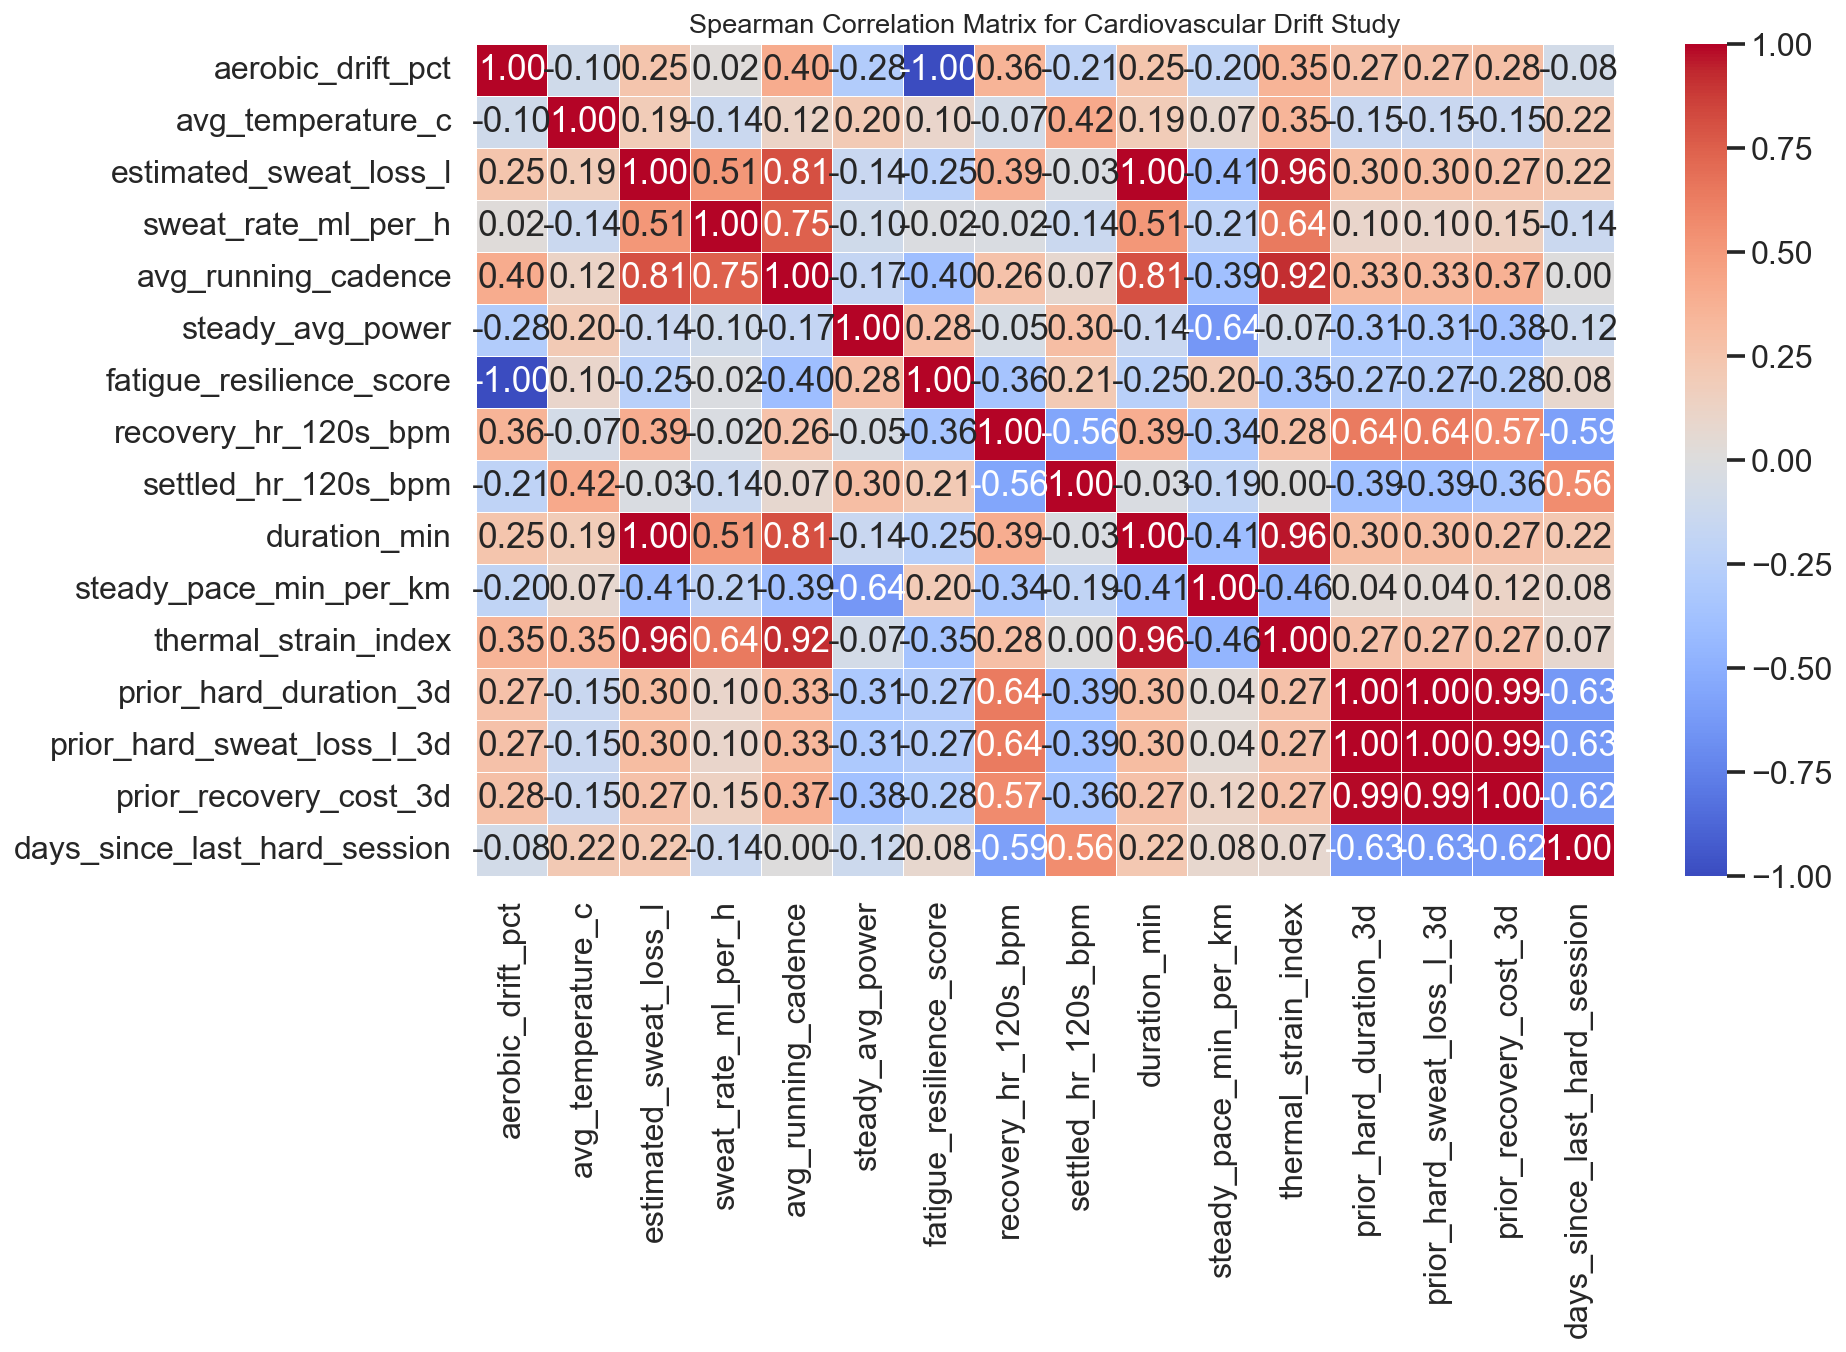

In [8]:
heatmap_features = ["aerobic_drift_pct", *[c for c in candidate_predictors if c in study_df.columns]]
corr_matrix = study_df[heatmap_features].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0.0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Matrix for Cardiovascular Drift Study")
plt.tight_layout()
plt.show()

## Regression and Feature Importance

A regularized linear model is used for interpretable coefficient estimates, and a random forest model is used as a non-parametric feature-importance check. Given the sample size, all inference should be treated as exploratory rather than confirmatory.

In [9]:
model_predictors = [
    "avg_temperature_c",
    "estimated_sweat_loss_l",
    "avg_running_cadence",
    "steady_avg_power",
    "fatigue_resilience_score",
    "recovery_hr_120s_bpm",
    "settled_hr_120s_bpm",
    "duration_min",
    "steady_pace_min_per_km",
    "prior_hard_duration_3d",
]

model_df = study_df[["aerobic_drift_pct", *model_predictors]].dropna().copy()
X = model_df[model_predictors]
y = model_df["aerobic_drift_pct"]

ridge_results = {}
feature_importance_df = pd.DataFrame(columns=["predictor", "standardized_coefficient", "rf_importance"])

if len(model_df) >= 6:
    ridge_pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-3, 3, 80)),
    )

    loo = LeaveOneOut()
    ridge_pred = cross_val_predict(ridge_pipe, X, y, cv=loo)

    ridge_pipe.fit(X, y)
    ridge_model = ridge_pipe.named_steps["ridgecv"]

    ridge_results = {
        "n": len(model_df),
        "alpha": float(ridge_model.alpha_),
        "mae": float(mean_absolute_error(y, ridge_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y, ridge_pred))),
        "r2": float(r2_score(y, ridge_pred)),
    }

    coefficients = pd.Series(ridge_model.coef_, index=model_predictors, name="standardized_coefficient")

    imputer = SimpleImputer(strategy="median")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=model_predictors, index=X.index)
    rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_leaf=1)
    rf.fit(X_imputed, y)
    rf_importance = pd.Series(rf.feature_importances_, index=model_predictors, name="rf_importance")

    feature_importance_df = pd.concat([coefficients, rf_importance], axis=1).reset_index().rename(columns={"index": "predictor"})
    feature_importance_df["abs_standardized_coefficient"] = feature_importance_df["standardized_coefficient"].abs()
    feature_importance_df = feature_importance_df.sort_values(["rf_importance", "abs_standardized_coefficient"], ascending=False).reset_index(drop=True)

    print(ridge_results)
    print(feature_importance_df.round(3))
else:
    print("Not enough complete observations for regression modeling.")

{'n': 10, 'alpha': 0.5422221006501586, 'mae': 1.7740177369677177, 'rmse': 2.0974283017457864, 'r2': -0.04262486525531717}
                  predictor  standardized_coefficient  rf_importance  abs_standardized_coefficient
0  fatigue_resilience_score                    -1.776          0.601                         1.776
1    estimated_sweat_loss_l                    -0.054          0.060                         0.054
2              duration_min                    -0.052          0.054                         0.052
3       settled_hr_120s_bpm                    -0.103          0.049                         0.103
4          steady_avg_power                     0.215          0.049                         0.215
5      recovery_hr_120s_bpm                     0.138          0.048                         0.138
6    steady_pace_min_per_km                     0.200          0.046                         0.200
7    prior_hard_duration_3d                    -0.132          0.040                  

## Longitudinal Adaptation Testing

Temporal trend analysis tests whether drift and related aerobic markers are changing over the training block. A simple early-versus-late split is also included to detect directional adaptation in a small sample.

In [10]:
def trend_test(df: pd.DataFrame, date_col: str, value_col: str) -> dict[str, float | str]:
    subset = df[[date_col, value_col]].dropna().copy()
    if len(subset) < 4:
        return {"metric": value_col, "n": len(subset), "slope_per_week": np.nan, "r": np.nan, "p": np.nan}

    x = subset[date_col].map(pd.Timestamp.toordinal).astype(float)
    y = subset[value_col].astype(float)
    fit = stats.linregress(x, y)
    return {
        "metric": value_col,
        "n": len(subset),
        "slope_per_week": float(fit.slope * 7.0),
        "r": float(fit.rvalue),
        "p": float(fit.pvalue),
    }


trend_metrics = [
    "aerobic_drift_pct",
    "steady_power_per_hr",
    "recovery_hr_120s_bpm",
    "settled_hr_120s_bpm",
    "avg_running_cadence",
    "fatigue_resilience_score",
]
trend_df = pd.DataFrame([trend_test(study_df, "date", metric) for metric in trend_metrics])
trend_df.round(4)

,metric,n,slope_per_week,r,p
0,aerobic_drift_pct,11,0.2756,0.2398,0.4776
1,steady_power_per_hr,11,0.0016,0.0935,0.7846
2,recovery_hr_120s_bpm,11,0.4366,0.2833,0.3986
3,settled_hr_120s_bpm,11,0.2529,0.1380,0.6858
4,avg_running_cadence,11,0.8741,0.7649,0.0061
5,fatigue_resilience_score,11,-3.2775,-0.2150,0.5255


In [11]:
split_index = max(1, len(study_df) // 2)
early_block = study_df.iloc[:split_index].copy()
late_block = study_df.iloc[split_index:].copy()

adaptation_rows = []
for metric in ["aerobic_drift_pct", "steady_power_per_hr", "recovery_hr_120s_bpm", "steady_pace_min_per_km"]:
    early = pd.to_numeric(early_block[metric], errors="coerce").dropna()
    late = pd.to_numeric(late_block[metric], errors="coerce").dropna()
    if len(early) >= 2 and len(late) >= 2:
        test = stats.mannwhitneyu(early, late, alternative="two-sided")
        adaptation_rows.append({
            "metric": metric,
            "early_median": float(np.median(early)),
            "late_median": float(np.median(late)),
            "delta_late_minus_early": float(np.median(late) - np.median(early)),
            "p": float(test.pvalue),
        })

adaptation_df = pd.DataFrame(adaptation_rows)
adaptation_df.round(4)

,metric,early_median,late_median,delta_late_minus_early,p
0,aerobic_drift_pct,5.400,7.8500,2.4500,0.1255
1,steady_power_per_hr,1.536,1.5315,-0.0045,0.7837
2,recovery_hr_120s_bpm,29.000,32.5000,3.5000,0.2633
3,steady_pace_min_per_km,7.390,7.3500,-0.0400,0.3558


## Publication-Quality Visualizations

The figure panel below is designed to function as a conference-poster summary: a longitudinal timeline, mechanistic scatter plots, and model-based importance ranking.

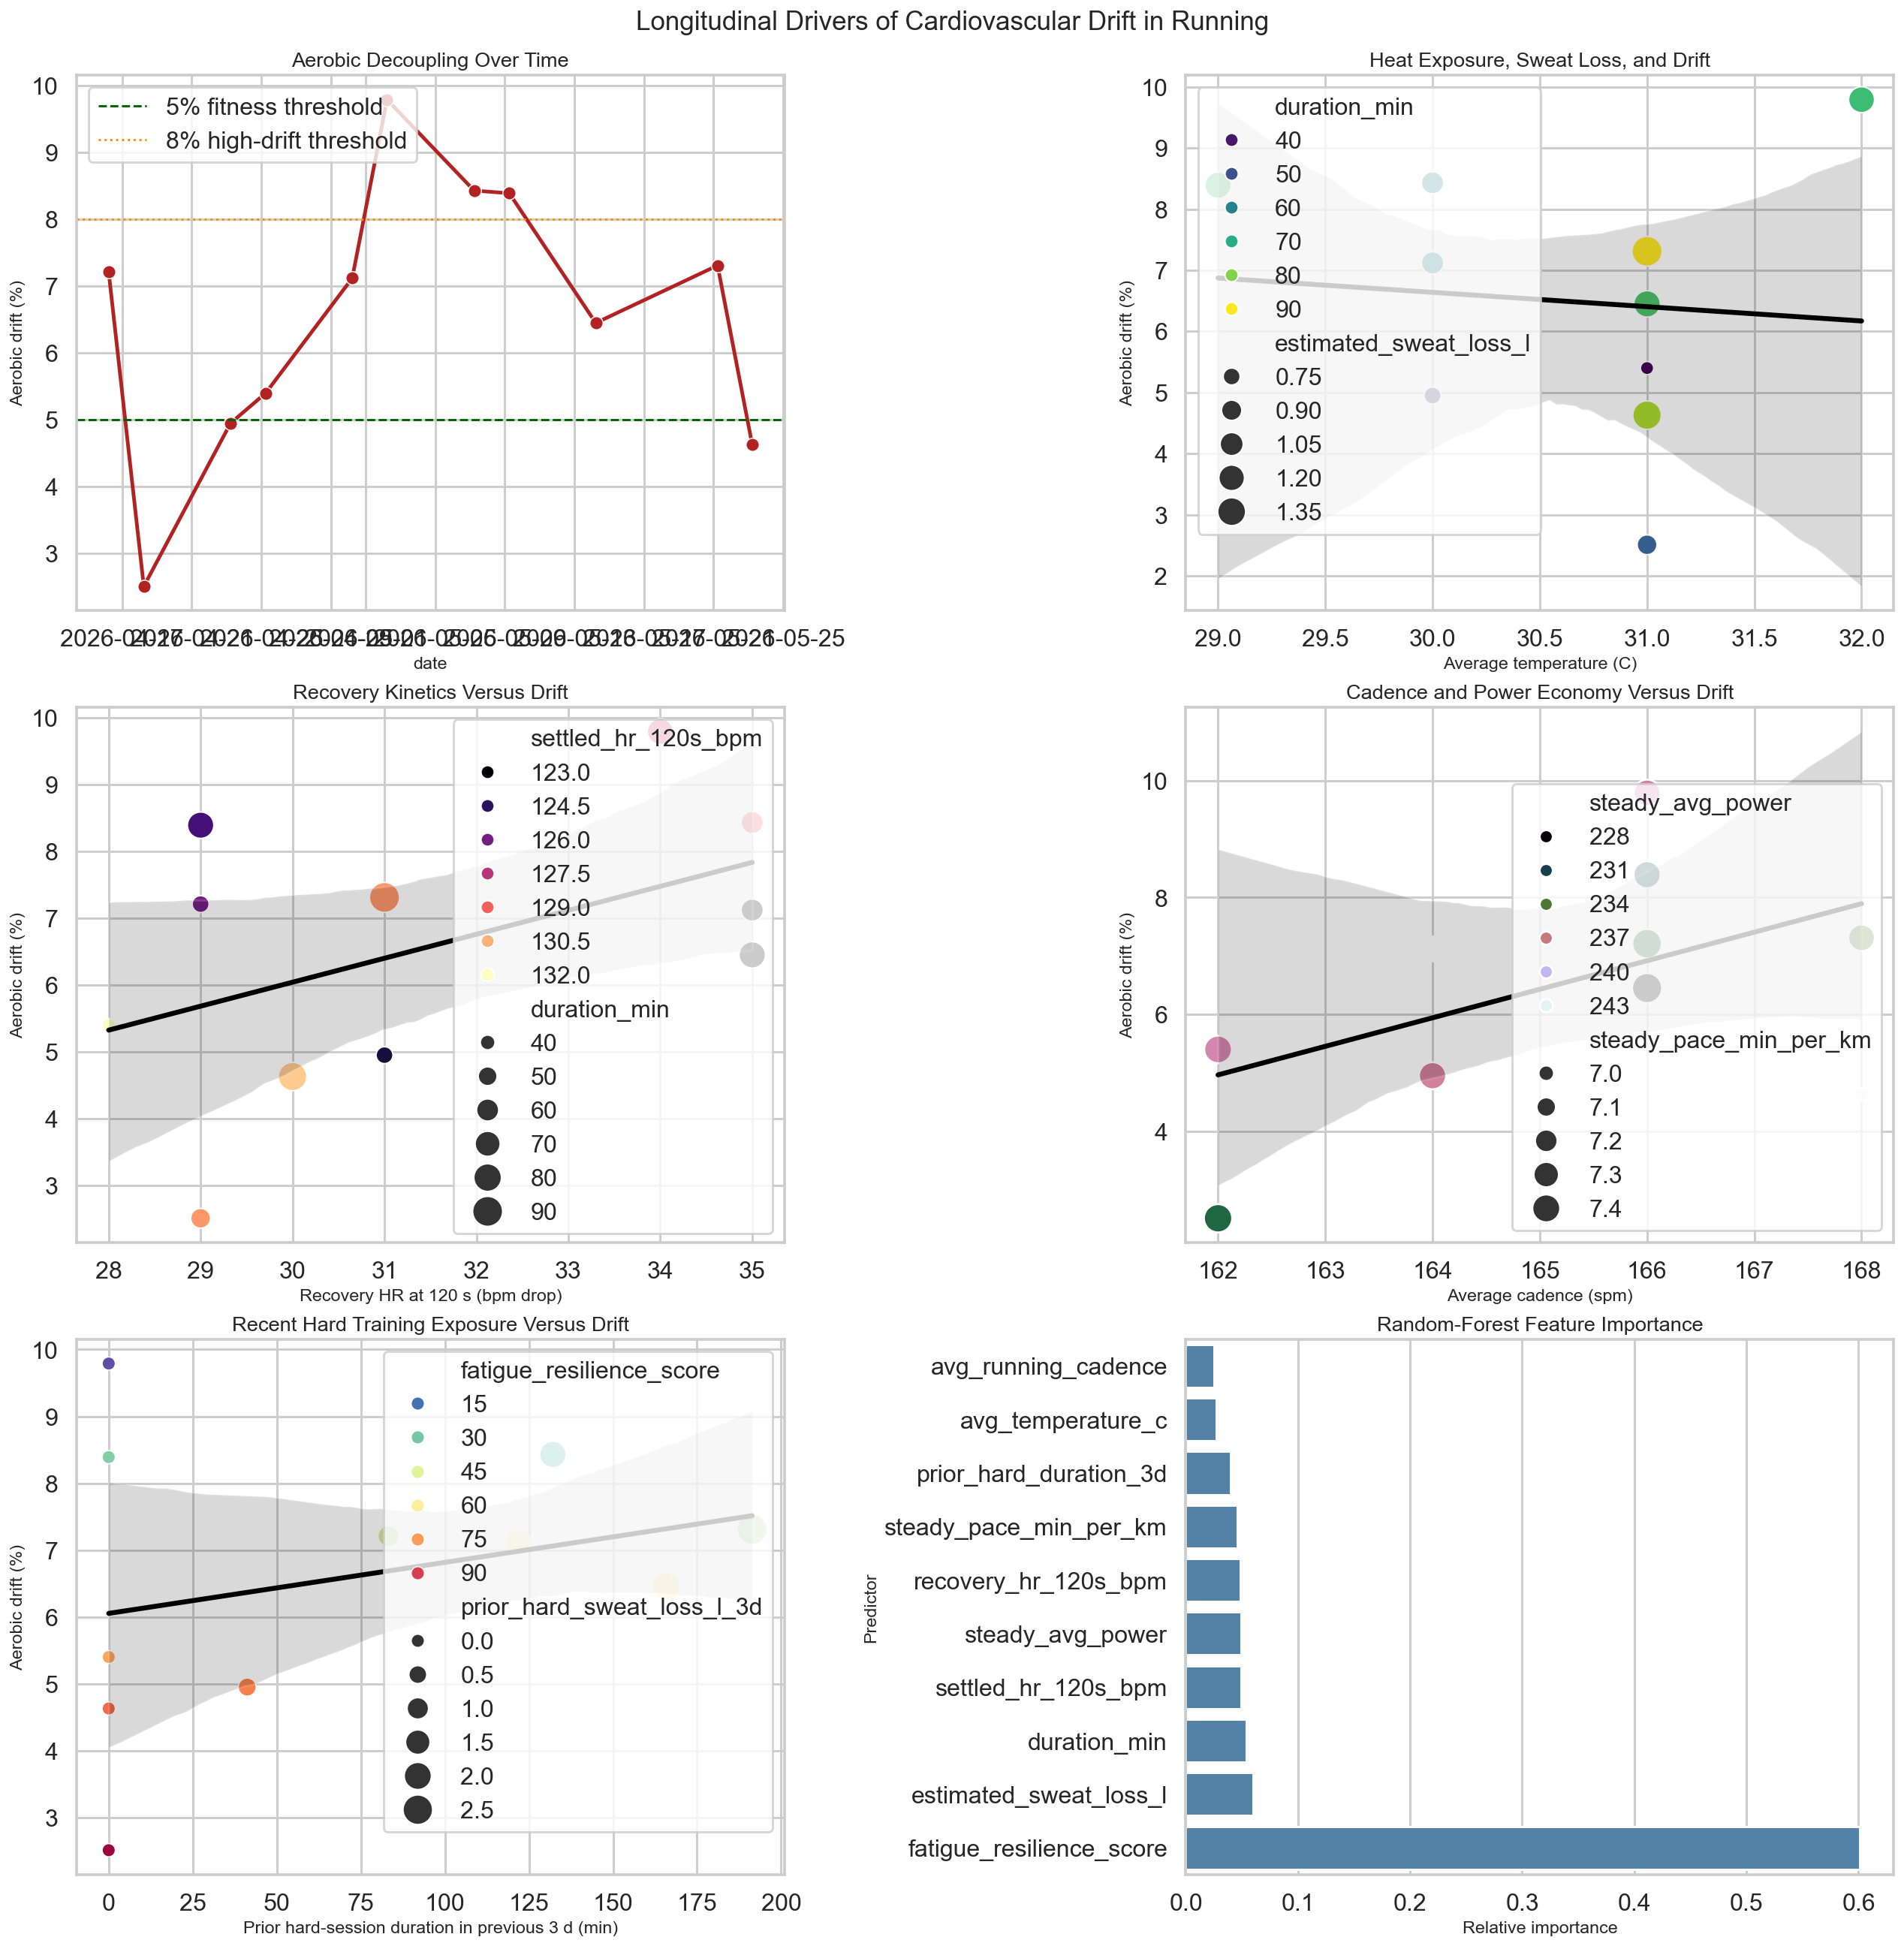

Saved figure panel to: C:\Users\A717631\repo\theEagle\reports\easy\cardiovascular_drift_research_panels.png


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18), constrained_layout=True)

timeline_ax = axes[0, 0]
sns.lineplot(data=study_df, x="date", y="aerobic_drift_pct", marker="o", linewidth=2.5, color="firebrick", ax=timeline_ax)
timeline_ax.axhline(5.0, linestyle="--", color="darkgreen", linewidth=1.5, label="5% fitness threshold")
timeline_ax.axhline(8.0, linestyle=":", color="darkorange", linewidth=1.5, label="8% high-drift threshold")
timeline_ax.set_title("Aerobic Decoupling Over Time")
timeline_ax.set_ylabel("Aerobic drift (%)")
timeline_ax.legend(loc="upper left")

heat_ax = axes[0, 1]
sns.scatterplot(
    data=study_df,
    x="avg_temperature_c",
    y="aerobic_drift_pct",
    size="estimated_sweat_loss_l",
    hue="duration_min",
    palette="viridis",
    sizes=(80, 420),
    ax=heat_ax,
)
sns.regplot(data=study_df, x="avg_temperature_c", y="aerobic_drift_pct", scatter=False, color="black", ax=heat_ax)
heat_ax.set_title("Heat Exposure, Sweat Loss, and Drift")
heat_ax.set_xlabel("Average temperature (C)")
heat_ax.set_ylabel("Aerobic drift (%)")

recovery_ax = axes[1, 0]
sns.scatterplot(
    data=study_df,
    x="recovery_hr_120s_bpm",
    y="aerobic_drift_pct",
    hue="settled_hr_120s_bpm",
    size="duration_min",
    palette="magma",
    sizes=(80, 420),
    ax=recovery_ax,
)
sns.regplot(data=study_df, x="recovery_hr_120s_bpm", y="aerobic_drift_pct", scatter=False, color="black", ax=recovery_ax)
recovery_ax.set_title("Recovery Kinetics Versus Drift")
recovery_ax.set_xlabel("Recovery HR at 120 s (bpm drop)")
recovery_ax.set_ylabel("Aerobic drift (%)")

economy_ax = axes[1, 1]
sns.scatterplot(
    data=study_df,
    x="avg_running_cadence",
    y="aerobic_drift_pct",
    hue="steady_avg_power",
    size="steady_pace_min_per_km",
    palette="cubehelix",
    sizes=(80, 420),
    ax=economy_ax,
)
sns.regplot(data=study_df, x="avg_running_cadence", y="aerobic_drift_pct", scatter=False, color="black", ax=economy_ax)
economy_ax.set_title("Cadence and Power Economy Versus Drift")
economy_ax.set_xlabel("Average cadence (spm)")
economy_ax.set_ylabel("Aerobic drift (%)")

load_ax = axes[2, 0]
sns.scatterplot(
    data=study_df,
    x="prior_hard_duration_3d",
    y="aerobic_drift_pct",
    hue="fatigue_resilience_score",
    size="prior_hard_sweat_loss_l_3d",
    palette="Spectral_r",
    sizes=(80, 420),
    ax=load_ax,
)
sns.regplot(data=study_df, x="prior_hard_duration_3d", y="aerobic_drift_pct", scatter=False, color="black", ax=load_ax)
load_ax.set_title("Recent Hard Training Exposure Versus Drift")
load_ax.set_xlabel("Prior hard-session duration in previous 3 d (min)")
load_ax.set_ylabel("Aerobic drift (%)")

importance_ax = axes[2, 1]
if not feature_importance_df.empty:
    plot_df = feature_importance_df.sort_values("rf_importance", ascending=True)
    sns.barplot(data=plot_df, x="rf_importance", y="predictor", color="steelblue", ax=importance_ax)
    importance_ax.set_title("Random-Forest Feature Importance")
    importance_ax.set_xlabel("Relative importance")
    importance_ax.set_ylabel("Predictor")
else:
    plot_df = correlation_df.head(8).sort_values("abs_spearman_r", ascending=True)
    sns.barplot(data=plot_df, x="abs_spearman_r", y="predictor", color="steelblue", ax=importance_ax)
    importance_ax.set_title("Top Absolute Spearman Associations")
    importance_ax.set_xlabel("Absolute Spearman r")
    importance_ax.set_ylabel("Predictor")

fig.suptitle("Longitudinal Drivers of Cardiovascular Drift in Running", fontsize=18, y=1.02)
POSTER_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(POSTER_OUTPUT, bbox_inches="tight")
plt.show()

print(f"Saved figure panel to: {POSTER_OUTPUT}")

## Automated Scientific Interpretation and Report Summary

The final cell synthesizes the descriptive, correlational, regression, and temporal findings into a research-style narrative summary suitable for internal reporting, poster notes, or manuscript drafting.

In [13]:
def format_p_value(p: float | None) -> str:
    if p is None or pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def direction_text(value: float) -> str:
    return "positive" if value > 0 else "negative"


top_correlates = correlation_df.head(5).copy()
top_correlation_lines = []
for _, row in top_correlates.iterrows():
    top_correlation_lines.append(
        f"- {row['predictor']}: Spearman r = {row['spearman_r']:.2f} ({direction_text(row['spearman_r'])}), p = {format_p_value(row['spearman_p'])}"
    )

trend_lines = []
for _, row in trend_df.iterrows():
    if pd.isna(row['slope_per_week']):
        continue
    trend_lines.append(
        f"- {row['metric']}: slope {row['slope_per_week']:+.3f} units per week, r = {row['r']:.2f}, p = {format_p_value(row['p'])}"
    )

adaptation_lines = []
for _, row in adaptation_df.iterrows():
    adaptation_lines.append(
        f"- {row['metric']}: early median {row['early_median']:.2f}, late median {row['late_median']:.2f}, delta {row['delta_late_minus_early']:+.2f}, p = {format_p_value(row['p'])}"
    )

if ridge_results:
    model_lines = [
        f"- Leave-one-out Ridge model: n = {ridge_results['n']}, alpha = {ridge_results['alpha']:.4f}, MAE = {ridge_results['mae']:.2f}, RMSE = {ridge_results['rmse']:.2f}, R2 = {ridge_results['r2']:.2f}.",
    ]
    if not feature_importance_df.empty:
        for _, row in feature_importance_df.head(5).iterrows():
            model_lines.append(
                f"- {row['predictor']}: standardized coefficient {row['standardized_coefficient']:+.2f}, random-forest importance {row['rf_importance']:.3f}."
            )
else:
    model_lines = ["- Regression modeling could not be completed because there were too few complete observations."]

first_date = study_df['date'].min().strftime('%Y-%m-%d')
last_date = study_df['date'].max().strftime('%Y-%m-%d')
median_drift = study_df['aerobic_drift_pct'].median()
median_ef = study_df['steady_power_per_hr'].median()
hot_runs = int((study_df['avg_temperature_c'] >= 30).sum())
high_drift_runs = int((study_df['aerobic_drift_pct'] >= 8).sum())

report_text = f"""# Cardiovascular Drift Longitudinal Research Summary

## Study Question
Which field-derived variables most strongly explain cardiovascular drift during easy running, and is there evidence of longitudinal adaptation across the observed training block?

## Cohort and Methods
- Observation window: {first_date} to {last_date}
- Easy runs analyzed for the primary outcome: {len(study_df)}
- Interval or threshold sessions used as antecedent exposure context: {len(interval_df)}
- Strength sessions used as antecedent exposure context: {len(strength_df)}
- Primary outcome: aerobic decoupling percentage from the easy-run steady section
- Statistical workflow: descriptive profiling, Spearman and Pearson correlation analysis, regularized regression, random-forest feature importance, linear trend testing, and early-versus-late non-parametric comparison

## Descriptive Findings
- Median aerobic drift was {median_drift:.2f}% across the easy-run timeline.
- Median efficiency factor was {median_ef:.3f} W/bpm.
- {hot_runs}/{len(study_df)} easy runs occurred at 30 C or hotter, indicating repeated thermal stress exposure.
- {high_drift_runs}/{len(study_df)} easy runs exceeded the 8% high-drift threshold.

## Strongest Associations With Drift
{chr(10).join(top_correlation_lines)}

## Regression and Feature Importance
{chr(10).join(model_lines)}

## Longitudinal Trend Analysis
{chr(10).join(trend_lines)}

## Early-versus-Late Adaptation Test
{chr(10).join(adaptation_lines)}

## Physiological Interpretation
Cardiovascular drift in this dataset appears to be multi-factorial rather than explained by a single determinant. The most plausible mechanistic candidates are thermoregulatory strain, hydration stress proxy, incomplete autonomic recovery, and residual fatigue from preceding hard training. Variables linked to movement economy and external power production should be interpreted as modulators rather than sole drivers.

When higher drift co-occurs with slower recovery heart-rate kinetics, higher settled post-exercise heart rate, higher temperature, and recent hard-session exposure, the pattern is most compatible with incomplete recovery and elevated cardiovascular strain. When drift falls over time alongside stable or improving efficiency factor, the pattern is more consistent with aerobic adaptation.

## Limitations
- Sample size is small, so all inferential results are exploratory.
- Garmin-derived running power, training effect, and some threshold-related values are vendor estimates rather than laboratory measurements.
- Heat and hydration are proxied from field data rather than direct core temperature or fluid-balance testing.
- Causal inference is not justified from this observational design alone.

## Practical Endurance-Science Conclusion
The working interpretation is that cardiovascular drift is most likely amplified by the interaction of heat exposure, sweat-loss burden, incomplete recovery kinetics, and recent hard training load. Longitudinal adaptation should be monitored primarily through repeated reductions in aerobic decoupling at matched durations, together with stable or improving efficiency factor and improved post-run heart-rate recovery.

## Output Artifacts
- Poster-style figure panel: {POSTER_OUTPUT}
- Markdown summary: {SUMMARY_OUTPUT}
"""

SUMMARY_OUTPUT.write_text(report_text, encoding="utf-8")
display_markdown(report_text)
print(f"Saved summary to: {SUMMARY_OUTPUT}")

# Cardiovascular Drift Longitudinal Research Summary

## Study Question
Which field-derived variables most strongly explain cardiovascular drift during easy running, and is there evidence of longitudinal adaptation across the observed training block?

## Cohort and Methods
- Observation window: 2026-04-16 to 2026-05-23
- Easy runs analyzed for the primary outcome: 11
- Interval or threshold sessions used as antecedent exposure context: 5
- Strength sessions used as antecedent exposure context: 10
- Primary outcome: aerobic decoupling percentage from the easy-run steady section
- Statistical workflow: descriptive profiling, Spearman and Pearson correlation analysis, regularized regression, random-forest feature importance, linear trend testing, and early-versus-late non-parametric comparison

## Descriptive Findings
- Median aerobic drift was 7.12% across the easy-run timeline.
- Median efficiency factor was 1.536 W/bpm.
- 9/11 easy runs occurred at 30 C or hotter, indicating repeated thermal stress exposure.
- 3/11 easy runs exceeded the 8% high-drift threshold.

## Strongest Associations With Drift
- fatigue_resilience_score: Spearman r = -1.00 (negative), p = <0.001
- avg_running_cadence: Spearman r = 0.40 (positive), p = 0.218
- recovery_hr_120s_bpm: Spearman r = 0.36 (positive), p = 0.281
- thermal_strain_index: Spearman r = 0.35 (positive), p = 0.318
- steady_avg_power: Spearman r = -0.28 (negative), p = 0.401

## Regression and Feature Importance
- Leave-one-out Ridge model: n = 10, alpha = 0.5422, MAE = 1.77, RMSE = 2.10, R2 = -0.04.
- fatigue_resilience_score: standardized coefficient -1.78, random-forest importance 0.601.
- estimated_sweat_loss_l: standardized coefficient -0.05, random-forest importance 0.060.
- duration_min: standardized coefficient -0.05, random-forest importance 0.054.
- settled_hr_120s_bpm: standardized coefficient -0.10, random-forest importance 0.049.
- steady_avg_power: standardized coefficient +0.22, random-forest importance 0.049.

## Longitudinal Trend Analysis
- aerobic_drift_pct: slope +0.276 units per week, r = 0.24, p = 0.478
- steady_power_per_hr: slope +0.002 units per week, r = 0.09, p = 0.785
- recovery_hr_120s_bpm: slope +0.437 units per week, r = 0.28, p = 0.399
- settled_hr_120s_bpm: slope +0.253 units per week, r = 0.14, p = 0.686
- avg_running_cadence: slope +0.874 units per week, r = 0.76, p = 0.006
- fatigue_resilience_score: slope -3.278 units per week, r = -0.22, p = 0.525

## Early-versus-Late Adaptation Test
- aerobic_drift_pct: early median 5.40, late median 7.85, delta +2.45, p = 0.126
- steady_power_per_hr: early median 1.54, late median 1.53, delta -0.00, p = 0.784
- recovery_hr_120s_bpm: early median 29.00, late median 32.50, delta +3.50, p = 0.263
- steady_pace_min_per_km: early median 7.39, late median 7.35, delta -0.04, p = 0.356

## Physiological Interpretation
Cardiovascular drift in this dataset appears to be multi-factorial rather than explained by a single determinant. The most plausible mechanistic candidates are thermoregulatory strain, hydration stress proxy, incomplete autonomic recovery, and residual fatigue from preceding hard training. Variables linked to movement economy and external power production should be interpreted as modulators rather than sole drivers.

When higher drift co-occurs with slower recovery heart-rate kinetics, higher settled post-exercise heart rate, higher temperature, and recent hard-session exposure, the pattern is most compatible with incomplete recovery and elevated cardiovascular strain. When drift falls over time alongside stable or improving efficiency factor, the pattern is more consistent with aerobic adaptation.

## Limitations
- Sample size is small, so all inferential results are exploratory.
- Garmin-derived running power, training effect, and some threshold-related values are vendor estimates rather than laboratory measurements.
- Heat and hydration are proxied from field data rather than direct core temperature or fluid-balance testing.
- Causal inference is not justified from this observational design alone.

## Practical Endurance-Science Conclusion
The working interpretation is that cardiovascular drift is most likely amplified by the interaction of heat exposure, sweat-loss burden, incomplete recovery kinetics, and recent hard training load. Longitudinal adaptation should be monitored primarily through repeated reductions in aerobic decoupling at matched durations, together with stable or improving efficiency factor and improved post-run heart-rate recovery.

## Output Artifacts
- Poster-style figure panel: C:\Users\A717631\repo\theEagle\reports\easy\cardiovascular_drift_research_panels.png
- Markdown summary: C:\Users\A717631\repo\theEagle\reports\easy\cardiovascular_drift_research_summary.md


Saved summary to: C:\Users\A717631\repo\theEagle\reports\easy\cardiovascular_drift_research_summary.md
